<a href="https://colab.research.google.com/github/Gobihanath/ZC-AI-Project-Management-ML-003/blob/main/Decision_Tree_project_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import libraries
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:
#installed version
print("sklearn version:", sklearn.__version__)

sklearn version: 1.6.1


In [7]:
#csv upload
from google.colab import files
uploaded = files.upload()

Saving project_risk_raw_dataset.csv to project_risk_raw_dataset (1).csv


In [8]:
df = pd.read_csv('project_risk_raw_dataset.csv')

In [9]:
df

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,PROJ_3996,IT,9,731548.97,14,5.40,9,Agile,Senior,4,...,Moderate,Occasional,NaN,NaN,Hybrid,Basic,10,1,1.1,High
3996,PROJ_3997,Healthcare,9,492981.40,9,2.69,8,Waterfall,Senior,5,...,Stable,Occasional,NaN,Basic,Hybrid,Basic,9,1,1.0,Medium
3997,PROJ_3998,IT,12,1097040.65,24,8.82,10,Kanban,Junior,2,...,Moderate,Regular,NaN,Basic,Fully Remote,Basic,3,4,1.0,High
3998,PROJ_3999,R&D,26,2900977.55,28,10.00,26,Scrum,Junior,1,...,High,Strategic,Basic,Formal,Fully Remote,Good,1,10,1.0,High


In [10]:
# Count of each class
target_counts = df['Risk_Level'].value_counts()
print("Target Distribution:\n", target_counts)


Target Distribution:
 Risk_Level
Medium      1396
High        1036
Low          806
Critical     762
Name: count, dtype: int64


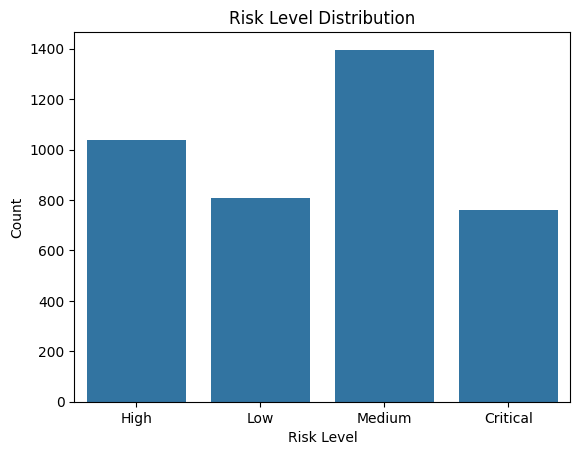

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
# Target distribution
sns.countplot(x='Risk_Level', data=df)
plt.title('Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.show()


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Project_ID                       4000 non-null   object 
 1   Project_Type                     4000 non-null   object 
 2   Team_Size                        4000 non-null   int64  
 3   Project_Budget_USD               4000 non-null   float64
 4   Estimated_Timeline_Months        4000 non-null   int64  
 5   Complexity_Score                 4000 non-null   float64
 6   Stakeholder_Count                4000 non-null   int64  
 7   Methodology_Used                 4000 non-null   object 
 8   Team_Experience_Level            4000 non-null   object 
 9   Past_Similar_Projects            4000 non-null   int64  
 10  External_Dependencies_Count      4000 non-null   int64  
 11  Change_Request_Frequency         4000 non-null   float64
 12  Project_Phase       

In [21]:
df.describe()

,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Team_Turnover_Rate,Vendor_Reliability_Score,...,Market_Volatility,Integration_Complexity,Resource_Availability,Organizational_Change_Frequency,Cross_Functional_Dependencies,Previous_Delivery_Success_Rate,Technical_Debt_Level,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor
count,4000.000000,4.000000e+03,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000
mean,15.388250,1.143032e+06,17.147750,6.192525,11.130500,1.973750,3.127750,1.638080,0.292725,0.712087,...,0.49716,5.573585,0.651695,1.212215,3.549250,0.750437,0.17544,6.492500,4.074500,1.011325
std,9.220969,5.908781e+05,6.926609,2.212538,4.425875,1.750093,1.609216,1.170451,0.166546,0.163418,...,0.28702,2.606654,0.201163,0.969191,2.320004,0.143712,0.29682,3.476416,2.883926,0.031694
min,2.000000,1.593555e+05,2.000000,1.620000,2.000000,0.000000,0.000000,0.010000,0.000000,0.090000,...,0.00000,1.000000,0.300000,0.000000,0.000000,0.150000,0.00000,1.000000,1.000000,1.000000
25%,9.000000,6.925329e+05,12.000000,4.460000,8.000000,1.000000,2.000000,0.760000,0.160000,0.600000,...,0.25000,3.317500,0.480000,0.500000,2.000000,0.660000,0.00000,4.000000,2.000000,1.000000
50%,13.000000,1.007472e+06,17.000000,6.015000,10.000000,2.000000,3.000000,1.370000,0.270000,0.730000,...,0.50000,5.600000,0.650000,0.960000,4.000000,0.770000,0.00000,7.000000,3.000000,1.000000
75%,20.000000,1.475870e+06,22.000000,7.862500,14.000000,3.000000,4.000000,2.230000,0.400000,0.840000,...,0.74000,7.860000,0.820000,1.660000,6.000000,0.860000,0.28000,10.000000,6.000000,1.000000
max,50.000000,3.768354e+06,36.000000,10.000000,29.000000,10.000000,7.000000,8.840000,0.850000,1.000000,...,1.00000,10.000000,1.000000,8.230000,7.000000,0.990000,1.00000,12.000000,17.000000,1.100000


In [22]:
print(df.columns)

Index(['Project_ID', 'Project_Type', 'Team_Size', 'Project_Budget_USD',
       'Estimated_Timeline_Months', 'Complexity_Score', 'Stakeholder_Count',
       'Methodology_Used', 'Team_Experience_Level', 'Past_Similar_Projects',
       'External_Dependencies_Count', 'Change_Request_Frequency',
       'Project_Phase', 'Requirement_Stability', 'Team_Turnover_Rate',
       'Vendor_Reliability_Score', 'Historical_Risk_Incidents',
       'Communication_Frequency', 'Regulatory_Compliance_Level',
       'Technology_Familiarity', 'Geographical_Distribution',
       'Stakeholder_Engagement_Level', 'Schedule_Pressure',
       'Budget_Utilization_Rate', 'Executive_Sponsorship', 'Funding_Source',
       'Market_Volatility', 'Integration_Complexity', 'Resource_Availability',
       'Priority_Level', 'Organizational_Change_Frequency',
       'Cross_Functional_Dependencies', 'Previous_Delivery_Success_Rate',
       'Technical_Debt_Level', 'Project_Manager_Experience',
       'Org_Process_Maturity', 'Dat

In [25]:
df['Risk_Level'].unique()

array(['High', 'Low', 'Medium', 'Critical'], dtype=object)

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Split data: 70% train, 10% test, 20% validation
df_train_val, df_val = train_test_split(df, test_size=0.2, stratify=df['Risk_Level'], random_state=42)
df_train, df_test = train_test_split(df_train_val, test_size=0.125, stratify=df_train_val['Risk_Level'], random_state=42)

# Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

print(len(df_train), len(df_test), len(df_val))  # Train, Test, Validation sizes


2800 400 800


In [14]:
# Print dataset counts
print(f"Training Data Count: {df_train.shape[0]}")
print(f"Testing Data Count: {df_test.shape[0]}")
print(f"Validation Data Count: {df_val.shape[0]}")

Training Data Count: 2800
Testing Data Count: 400
Validation Data Count: 800


In [33]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np

def dt_model_training(df_train_test, df_val):

    target_col = 'Risk_Level'

    # Irrelevant columns + redundant correlated features removed
    drop_cols = [
        'Project_ID',
        'Complexity_Score', 'Change_Request_Frequency', 'Team_Turnover_Rate',
        'Communication_Frequency', 'Geographical_Distribution', 'Market_Volatility',
        'Cross_Functional_Dependencies', 'Technical_Debt_Level', 'Seasonal_Risk_Factor',
        'Project_Budget_USD',
    ]

    # Keep influential features
    feature_cols = [col for col in df_train_test.columns if col not in drop_cols + [target_col]]

    categorical_cols = df_train_test[feature_cols].select_dtypes(include=['object', 'bool']).columns.tolist()

    # Prepare training features
    X = df_train_test[feature_cols].copy()
    X[categorical_cols] = X[categorical_cols].astype("category")
    X = pd.get_dummies(X, columns=categorical_cols)
    X.fillna(0, inplace=True)

    # Prepare target labels
    y = df_train_test[target_col].copy()
    le = LabelEncoder()
    y = le.fit_transform(y)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # ------------------------------
    # RANDOM SEARCH HYPERPARAM TUNING
    # ------------------------------
    param_dist = {
        "criterion": ["gini", "entropy", "log_loss"],
        "max_depth": np.arange(4, 30),
        "min_samples_split": np.arange(2, 20),
        "min_samples_leaf": np.arange(1, 15),
        "max_features": ["sqrt", "log2", None],
        "class_weight": [None, "balanced"],
        "splitter": ["best", "random"]
    }

    dt = DecisionTreeClassifier(random_state=42)

    random_search = RandomizedSearchCV(
        estimator=dt,
        param_distributions=param_dist,
        n_iter=60,                  # More iterations → better search
        scoring="accuracy",
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    random_search.fit(X_train, y_train)
    model = random_search.best_estimator_

    print("\nBest Hyperparameters Found:")
    print(random_search.best_params_)

    # ------------------------------
    # TEST PERFORMANCE
    # ------------------------------
    print("\nTesting Dataset Performance")
    print("#" * 80)

    y_test_pred = model.predict(X_test)

    print(f"Accuracy:  {accuracy_score(y_test, y_test_pred) * 100:.2f}%")
    print(f"Precision: {precision_score(y_test, y_test_pred, average='weighted') * 100:.2f}%")
    print(f"Recall:    {recall_score(y_test, y_test_pred, average='weighted') * 100:.2f}%")
    print(f"F1 Score:  {f1_score(y_test, y_test_pred, average='weighted') * 100:.2f}%")

    # ------------------------------
    # VALIDATION SET PERFORMANCE
    # ------------------------------
    print("\nValidation Dataset Performance")
    print("#" * 80)

    X_val = df_val[feature_cols].copy()
    X_val[categorical_cols] = X_val[categorical_cols].astype("category")
    X_val = pd.get_dummies(X_val, columns=categorical_cols)

    # Align with training features
    X_val = X_val.reindex(columns=X.columns, fill_value=0)
    X_val.fillna(0, inplace=True)

    y_val = le.transform(df_val[target_col])
    y_val_pred = model.predict(X_val)

    print(f"Accuracy:  {accuracy_score(y_val, y_val_pred) * 100:.2f}%")
    print(f"Precision: {precision_score(y_val, y_val_pred, average='weighted') * 100:.2f}%")
    print(f"Recall:    {recall_score(y_val, y_val_pred, average='weighted') * 100:.2f}%")
    print(f"F1 Score:  {f1_score(y_val, y_val_pred, average='weighted') * 100:.2f}%")

    return model, y_val, y_val_pred, le


# Usage
df_train_test, df_val = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['Risk_Level']
)

model, y_val, y_val_pred, le = dt_model_training(df_train_test, df_val)


Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Hyperparameters Found:
{'splitter': 'random', 'min_samples_split': np.int64(8), 'min_samples_leaf': np.int64(4), 'max_features': None, 'max_depth': np.int64(9), 'criterion': 'log_loss', 'class_weight': None}

Testing Dataset Performance
################################################################################
Accuracy:  41.46%
Precision: 42.46%
Recall:    41.46%
F1 Score:  40.26%

Validation Dataset Performance
################################################################################
Accuracy:  42.75%
Precision: 43.69%
Recall:    42.75%
F1 Score:  41.67%


In [16]:

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

def dt_model_training(df_train_test, df_val):


    target_col = 'Risk_Level'

    # Irrelevant columns + redundant correlated features removed
    drop_cols = [
        'Project_ID',
        'Complexity_Score', 'Change_Request_Frequency', 'Team_Turnover_Rate',
        'Communication_Frequency', 'Geographical_Distribution', 'Market_Volatility',
        'Cross_Functional_Dependencies', 'Technical_Debt_Level', 'Seasonal_Risk_Factor',

        # remove redundant highly correlated variables
         'Project_Budget_USD',          # high corr with Timeline, Team, Stakeholders
    ]

    # Keep Influential features
    feature_cols = [col for col in df_train_test.columns if col not in drop_cols + [target_col]]

    # Identify categorical columns
    categorical_cols = df_train_test[feature_cols].select_dtypes(include=['object', 'bool']).columns.tolist()

    # Prepare training features
    X = df_train_test[feature_cols].copy()
    X[categorical_cols] = X[categorical_cols].astype("category")
    X = pd.get_dummies(X, columns=categorical_cols)
    X.fillna(0, inplace=True)

    # Prepare target labels
    y = df_train_test[target_col].copy()
    le = LabelEncoder()
    y = le.fit_transform(y)

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Increase accuracy using tuning
    model = DecisionTreeClassifier(
        random_state=42,
        criterion='entropy',  # better splits for categorical-heavy data
        max_depth=8,          # prevent overfitting
        min_samples_split=8,  # smoother decision boundaries
        min_samples_leaf=5,   # reduce noise
        class_weight='balanced'  # handle class imbalance
    )

    model.fit(X_train, y_train)

    ########## TEST PERFORMANCE
    print("\nTesting Dataset Performance")
    print("#" * 80)

    y_test_pred = model.predict(X_test)

    print(f"Accuracy:  {accuracy_score(y_test, y_test_pred) * 100:.2f}%")
    print(f"Precision: {precision_score(y_test, y_test_pred, average='weighted') * 100:.2f}%")
    print(f"Recall:    {recall_score(y_test, y_test_pred, average='weighted') * 100:.2f}%")
    print(f"F1 Score:  {f1_score(y_test, y_test_pred, average='weighted') * 100:.2f}%")


    ########## VALIDATION ON df_val
    print("\nValidation Dataset Performance")
    print("#" * 80)

    X_val = df_val[feature_cols].copy()
    X_val[categorical_cols] = X_val[categorical_cols].astype("category")
    X_val = pd.get_dummies(X_val, columns=categorical_cols)

    # Align with training columns
    X_val = X_val.reindex(columns=X.columns, fill_value=0)
    X_val.fillna(0, inplace=True)

    y_val = le.transform(df_val[target_col])
    y_val_pred = model.predict(X_val)

    print(f"Accuracy:  {accuracy_score(y_val, y_val_pred) * 100:.2f}%")
    print(f"Precision: {precision_score(y_val, y_val_pred, average='weighted') * 100:.2f}%")
    print(f"Recall:    {recall_score(y_val, y_val_pred, average='weighted') * 100:.2f}%")
    print(f"F1 Score:  {f1_score(y_val, y_val_pred, average='weighted') * 100:.2f}%")

    return model, y_val, y_val_pred, le


# Usage
df_train_test, df_val = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['Risk_Level']
)

model, y_val, y_val_pred, le = dt_model_training(df_train_test, df_val)


Testing Dataset Performance
################################################################################
Accuracy:  45.94%
Precision: 46.22%
Recall:    45.94%
F1 Score:  46.03%

Validation Dataset Performance
################################################################################
Accuracy:  41.38%
Precision: 41.81%
Recall:    41.38%
F1 Score:  41.52%


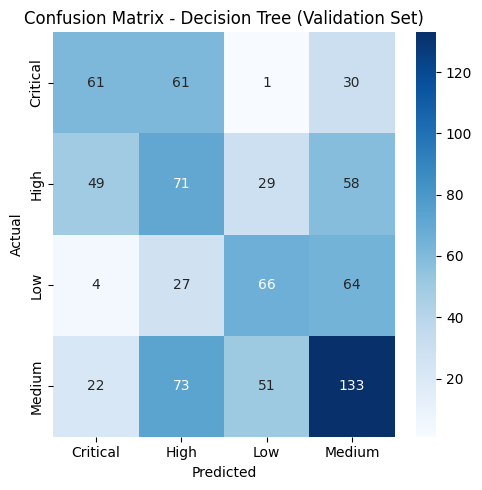

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = le.transform(df_val['Risk_Level'])  # encode validation target
y_pred = y_val_pred

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Use original class labels for display
labels = le.classes_

# Plot
plt.figure(figsize=(5,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Decision Tree (Validation Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



Top Feature Importances:
Team_Experience_Level_Expert                  0.086606
Technology_Familiarity_New                    0.076325
Org_Process_Maturity_Ad-hoc                   0.073918
Industry_Volatility_Extreme                   0.051480
Key_Stakeholder_Availability_Excellent        0.044321
Stakeholder_Engagement_Level_Excellent        0.038090
Executive_Sponsorship_Strong                  0.034245
Resource_Contention_Level_Low                 0.033144
Change_Control_Maturity_Advanced              0.028641
Industry_Volatility_Stable                    0.025325
Technology_Familiarity_Expert                 0.024669
Client_Experience_Level_Strategic             0.021592
Risk_Management_Maturity_Advanced             0.019382
Current_Phase_Duration_Months                 0.019102
Contract_Type_Time & Materials                0.018663
Project_Manager_Experience_Junior PM          0.016613
Key_Stakeholder_Availability_Poor             0.015888
Project_Manager_Experience_Certified PM

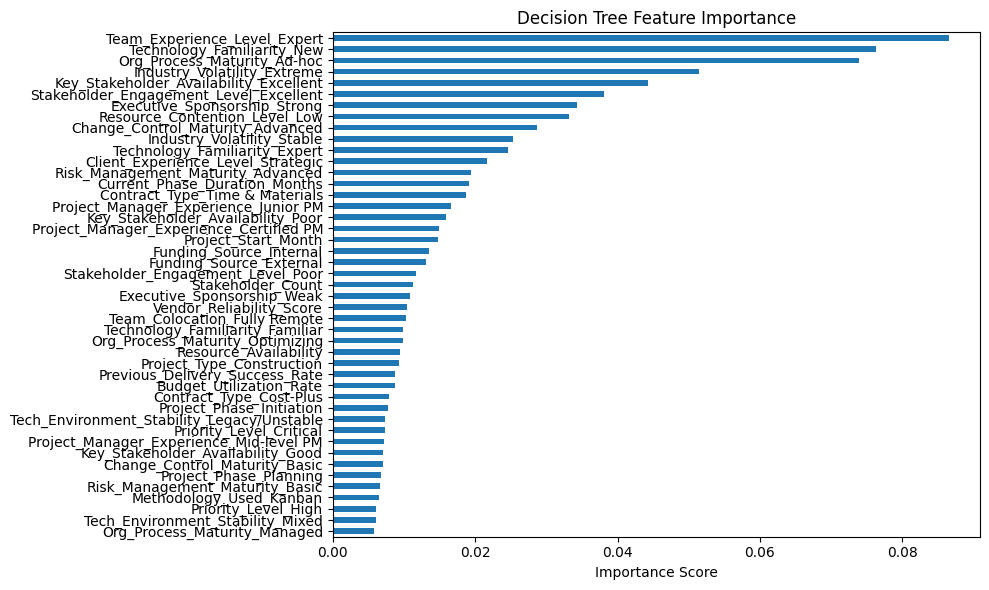

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# ====== RECREATE FEATURE COLUMNS ======
drop_cols = [
    'Project_ID', 'Complexity_Score', 'Change_Request_Frequency', 'Team_Turnover_Rate',
    'Communication_Frequency', 'Geographical_Distribution', 'Market_Volatility',
    'Cross_Functional_Dependencies', 'Technical_Debt_Level', 'Seasonal_Risk_Factor',
    'Project_Budget_USD'
]
target_col = "Risk_Level"

feature_cols = [c for c in df_train_test.columns if c not in drop_cols + [target_col]]
categorical_cols = df_train_test[feature_cols].select_dtypes(include=['object', 'bool']).columns.tolist()

# ====== PREPARE TRAIN FEATURES ======
X_train = df_train_test[feature_cols].copy()
X_train[categorical_cols] = X_train[categorical_cols].astype("category")
X_train = pd.get_dummies(X_train, columns=categorical_cols).fillna(0)

# ====== FEATURE IMPORTANCE ======
fi = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("\nTop Feature Importances:")
print(fi.head(45))

plt.figure(figsize=(10, 6))
fi.head(45).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [ ]:
import joblib
import os

# Specify the desired folder path
folder_path = r'F:\new_pro\R&D\ZC-AI-Project-Management-ML-003'
os.makedirs(folder_path, exist_ok=True)  # create folder if it doesn't exist

# File name for Decision Tree model
file_path = os.path.join(folder_path, 'Decision_Tree_Model_Train_Rework.pkl')

# Save the trained Decision Tree model
joblib.dump(model, file_path)

print(f"Decision Tree model saved successfully at: {file_path}")


Decision Tree model saved successfully at: F:\new_pro\R&D\ZC-AI-Project-Management-ML-003/Decision_Tree_Model_Train_Rework.pkl
